# LOAD AND EXPLORATORY ANALYSIS OF THE VTC DATASET

Description:
   This notebook performs an initial data exploration of the VTC dataset.
   The goal is to understand the structure, quality, and relationships
   between the four main entities: `cars`, `drivers`, `trips`, and `users`.

It is structured by:
   - Initial load of the `dataset.zip`
   - Exploratory data analysis
        - BASIC STRUCTURE & OVERVIEW
        - UNIQUE, NULL AND DUPLICATE CHECKS
        - DATE RANGE ANALYSIS
        - RELATIONSHIP CHECKS BETWEEN FACT AND DIMENSIONS
   - Tests with the different data tables
   - Conclusions and Next Steps in Data Modeling

## 1. Initial load of the dataset.zip
ZIP --> JSON --> `Pandas` DataFrames (df)

In [1]:
import sys, os

# Add the project's root folder to the sys.path to be able to work with the notebook
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import zipfile
import pandas as pd

from src.utils.db_connection import get_connection
from src.utils.unzip_dataset import unzip_dataset
from src.utils.load_ndjson import load_ndjson 

In [3]:
unzip_dataset()

[OK] Dataset unzipped in C:\Users\Diego Prieto\Documents\data-engineering-analytics-challenge-candidate-zZkODJhOTd\data\extracted
[INFO] '__MACOSX' folder removed
[INFO] Content moved from 'dataset/' to data/extracted/


WindowsPath('C:/Users/Diego Prieto/Documents/data-engineering-analytics-challenge-candidate-zZkODJhOTd/data/extracted')

In [4]:
# Path where the JSON Lines files are located
DATASET_DIR = "../data/extracted"

# We go through all the files in the directory
for filename in os.listdir(DATASET_DIR):
    if filename.endswith(".json"):
        file_path = os.path.join(DATASET_DIR, filename)
        var_name = "df_" + os.path.splitext(filename)[0]  # e.g.: df_cars

        try:
            print(f"Loading file: {filename}...")
            
            # Use the custom function that handles errors and invalid records
            df = load_ndjson(file_path, save_invalid=True)

            # We create the global variable dynamically (e.g.: df_cars)
            globals()[var_name] = df

            print(f"✅ {var_name} loaded correctly ({len(df)} valid records).")
            
            print() 

        except Exception as e:
            print(f"❌ Error when loading {filename}: {e}")
            print()


Loading file: cars.json...
✅ 16000 valid records loaded from cars.json.
🔧 0 lines were automatically repaired.
✅ df_cars loaded correctly (16000 valid records).

Loading file: drivers.json...
✅ 15183 valid records loaded from drivers.json.
🔧 0 lines were automatically repaired.
✅ df_drivers loaded correctly (15183 valid records).

Loading file: trip.json...
✅ 23920 valid records loaded from trip.json.
🔧 30 lines were automatically repaired.
✅ df_trip loaded correctly (23920 valid records).

Loading file: users.json...
✅ 99 valid records loaded from users.json.
🔧 0 lines were automatically repaired.
✅ df_users loaded correctly (99 valid records).



## 2. Exploratory data analysis

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

dfs = {
    'cars': df_cars,
    'drivers': df_drivers,
    'trips': df_trip,
    'users': df_users
}

for name, df in dfs.items():
    print(f"{name}: {df.shape[0]} records, {df.shape[1]} columns")

cars: 16000 records, 8 columns
drivers: 15183 records, 5 columns
trips: 23920 records, 10 columns
users: 99 records, 7 columns


### BASIC STRUCTURE & OVERVIEW

Will give us insight on the available columns per entity and allow us to start thinking about the possible insights, stats and metris that can be obtained from the dataset.

In [6]:
print("Dataset overview:")
for name, df in dfs.items():
    print(f"\n{'='*10} {name.upper()} {'='*10}")
    display(df.head(3))
    display(df.info())

Dataset overview:

========== CARS ==========


,_id,licensed,disabled,icon,reg_plate,created_at,updated_at,product_ids
0,hnfxkvbiDF0koqEE1SuZTw==,True,False,lite,t+ruRYKrpwcAZ3Ysy1+E2A==,2022-01-02 12:17:43.399 UTC,2022-01-02 12:17:43.399 UTC,[]
1,wIZCi+KE76hXhA7TtAqCkA==,True,False,lite,qDaOk2YLISBgM+umWmWg4Q==,2019-12-26 20:50:29.43 UTC,2022-01-02 02:52:03.973 UTC,[]
2,Ub5a/RobCL6nr1RMPCspyg==,True,False,lite,5p/dpc6ichmsRNdezl1RsQ==,2022-01-02 16:45:21.793 UTC,2022-01-02 16:45:21.793 UTC,[]


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   _id          16000 non-null  object
 1   licensed     16000 non-null  bool  
 2   disabled     16000 non-null  bool  
 3   icon         16000 non-null  object
 4   reg_plate    16000 non-null  object
 5   created_at   16000 non-null  object
 6   updated_at   16000 non-null  object
 7   product_ids  16000 non-null  object
dtypes: bool(2), object(6)
memory usage: 781.4+ KB


None


========== DRIVERS ==========


...

None


========== USERS ==========


,id,name,mobile_num,email,created_at,updated_at,locale
0,HWwdI596TFjbJyQZlpkL+Q==,jBOOvUzxYBjOQ+rkhigtYw==,AfmanJqAKj0dhUUR5fd0eA==,AgpGVcrYjZ0c7pwIlmwm1Q==,2017-10-05 08:14:20.086 UTC,2021-10-04 11:51:15.132 UTC,en-AR
1,HSwQCSgrzWuHSc/Zb5ZfIQ==,vY6pWff5Q3L7CaZlgrILGw==,DqJ8m/yjMayJfb6ePoDVFg==,x3N/CB0orcGDJiYqOFsofw==,2017-02-18 17:18:06.301 UTC,2021-09-30 12:54:30.036 UTC,en-AR
2,80+QqLj09GxQ4KvptbnJIg==,QE4u+FJ4P03Y+vEYzIe+7w==,rvO0ka7AJdYe4tlr54kcpw==,3PjlmUXvj8hXKknoghIJcA==,2017-09-01 21:57:03.121 UTC,2021-09-30 01:16:17.299 UTC,en-AR


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          99 non-null     object
 1   name        99 non-null     object
 2   mobile_num  99 non-null     object
 3   email       99 non-null     object
 4   created_at  99 non-null     object
 5   updated_at  99 non-null     object
 6   locale      99 non-null     object
dtypes: object(7)
memory usage: 5.5+ KB


None

In [7]:
import json

if "user" in df_trip.columns:
    df_trip = df_trip.rename(columns={"user": "user_id"})

if "stops" in df_trip.columns:
    df_trip["stops"] = df_trip["stops"].apply(
        lambda x: json.dumps(x) if isinstance(x, (list, dict)) else json.dumps([])
    )

### UNIQUE, NULL AND DUPLICATE CHECKS

In [8]:
id_columns = {
    'cars': '_id',
    'drivers': 'id',
    'users': 'id',
    'trips': 'id'
}

summary = []

for name, df in dfs.items():
    id_col = id_columns.get(name)
    if id_col not in df.columns:
        print(f"{name}: Column ID '{id_col}' not found, omitted.")
        continue

    total_rows = len(df)
    null_ids = df[id_col].isna().sum()
    distinct_ids = df[id_col].nunique(dropna=True)
    duplicated_ids = total_rows - distinct_ids - null_ids
    
    summary.append({
        'table': name,
        'id_column': id_col,
        'total_rows': total_rows,
        'distinct_ids': distinct_ids,
        'null_ids': null_ids,
        'duplicated_ids': duplicated_ids
    })

df_id_quality = pd.DataFrame(summary)
print("Checking for duplicates, nulls, and unique IDs...\n")
display(df_id_quality)

Checking for duplicates, nulls, and unique IDs...



,table,id_column,total_rows,distinct_ids,null_ids,duplicated_ids
0,cars,_id,16000,14535,0,1465
1,drivers,id,15183,1564,0,13619
2,trips,id,23920,1867,0,22053
3,users,id,99,99,0,0


In [9]:
for name, df in dfs.items():
    print(f"\n{name.upper()} — NULL values:")
    display(df.isna().sum())


CARS — NULL values:


_id            0
licensed       0
disabled       0
icon           0
reg_plate      0
created_at     0
updated_at     0
product_ids    0
dtype: int64


DRIVERS — NULL values:


id                0
name              0
created_at        0
updated_at        0
state         14379
dtype: int64


TRIPS — NULL values:


id                0
created_at        0
updated_at        0
user              0
reason            0
start_at          0
driver            0
car               0
stops             0
price         18631
dtype: int64


USERS — NULL values:


id            0
name          0
mobile_num    0
email         0
created_at    0
updated_at    0
locale        0
dtype: int64

In [11]:
key_cols = {
    'cars': ['_id'],
    'drivers': ['id'],
    'users': ['id'],
    'trips': ['id'] 
}

for name, df in dfs.items():
    if all(col in df.columns for col in key_cols[name]):
        duplicates = df.duplicated(subset=key_cols[name]).sum()
        print(f"{name.upper()} — {duplicates} key-based duplicates {key_cols[name]}")
    else:
        print(f"{name.upper()} — No defined key found")


CARS — 1465 key-based duplicates ['_id']
DRIVERS — 13619 key-based duplicates ['id']
TRIPS — 22053 key-based duplicates ['id']
USERS — 0 key-based duplicates ['id']


### DATE RANGE ANALYSIS

In [12]:
for name in ['cars', 'drivers', 'users', 'trips']:
    if 'created_at' in dfs[name].columns:
        print(f"\n{name.upper()} - date ranges:")
        print(f"Since: {dfs[name]['created_at'].min()}  To: {dfs[name]['created_at'].max()}")



CARS - date ranges:
Since: 2016-04-06 17:48:16.883 UTC  To: 2022-01-24 12:38:24.892 UTC

DRIVERS - date ranges:
Since: 2014-09-22 18:18:23.748 UTC  To: 2021-09-30 16:23:04.646 UTC

USERS - date ranges:
Since: 2012-01-25 08:32:14 UTC  To: 2018-02-11 19:06:35.148 UTC

TRIPS - date ranges:
Since: 2021-09-01 21:09:23.986 UTC  To: 2021-10-07 16:50:41.352 UTC


We have few data from trips, only from 2021-09-01 to 2021-10-07.

### RELATIONSHIP CHECKS BETWEEN FACT AND DIMENSIONS

Using `duckdb` to do SQL queries over the Pandas dfs:

In [13]:
import duckdb

print("\nChecking relationships between TRIPS and dimensions (USERS, DRIVERS, CARS)...\n")

# Register DataFrames in DuckDB
con = duckdb.connect(database=':memory:')
con.register("trips", df_trip)
con.register("drivers", df_drivers)
con.register("cars", df_cars)
con.register("users", df_users)


Checking relationships between TRIPS and dimensions (USERS, DRIVERS, CARS)...



In [16]:
queries = {
    "drivers_coverage": """
        SELECT
            COUNT(DISTINCT t.driver) AS distinct_drivers_in_trips,
            COUNT(DISTINCT CASE WHEN d.id IS NOT NULL THEN t.driver END) AS drivers_with_dim,
            ROUND(
                100.0 * COUNT(DISTINCT CASE WHEN d.id IS NOT NULL THEN t.driver END)
                / NULLIF(COUNT(DISTINCT t.driver), 0),
                2
            ) AS pct_drivers_with_dim
        FROM trips t
        LEFT JOIN drivers d
            ON t.driver = d.id
    """,
    "cars_coverage": """
        SELECT
            COUNT(DISTINCT t.car) AS distinct_cars_in_trips,
            COUNT(DISTINCT CASE WHEN c._id IS NOT NULL THEN t.car END) AS cars_with_dim,
            ROUND(
                100.0 * COUNT(DISTINCT CASE WHEN c._id IS NOT NULL THEN t.car END)
                / NULLIF(COUNT(DISTINCT t.car), 0),
                2
            ) AS pct_cars_with_dim
        FROM trips t
        LEFT JOIN cars c
            ON t.car = c._id
    """,
    "users_coverage": """
        SELECT
            COUNT(DISTINCT t.user_id) AS distinct_users_in_trips,
            COUNT(DISTINCT CASE WHEN u.id IS NOT NULL THEN t.user_id END) AS users_with_dim,
            ROUND(
                100.0 * COUNT(DISTINCT CASE WHEN u.id IS NOT NULL THEN t.user_id END)
                / NULLIF(COUNT(DISTINCT t.user_id), 0),
                2
            ) AS pct_users_with_dim
        FROM trips t
        LEFT JOIN users u
            ON t.user_id = u.id
    """,
}

These queries check how many drivers, cars, and users from the trips table also exist in their corresponding dimension tables, and show the percentage of matches to see how complete the data is.

In [17]:
for name, sql in queries.items():
    print(f"{name.replace('_', ' ').title()}")
    display(con.execute(sql).df())

Drivers Coverage


,distinct_drivers_in_trips,drivers_with_dim,pct_drivers_with_dim
0,1566,1564,99.87


Cars Coverage


,distinct_cars_in_trips,cars_with_dim,pct_cars_with_dim
0,1563,62,3.97


Users Coverage


,distinct_users_in_trips,users_with_dim,pct_users_with_dim
0,99,99,100.0


Drivers present in trips but missing in drivers dimension:

In [15]:
missing_drivers = con.execute("""
    SELECT DISTINCT t.driver
    FROM trips t
    LEFT JOIN drivers d ON t.driver = d.id
    WHERE d.id IS NULL
""").df()

print("Drivers present in TRIPS but missing in DIM_DRIVERS:")
display(missing_drivers.head(20))
print(f"Total missing drivers: {len(missing_drivers)}")


Drivers present in TRIPS but missing in DIM_DRIVERS:


,driver
0,3C2Pr+Jai3Pl33WXZh1+Dg==
1,1B2M2Y8AsgTpgAmY7PhCfg==


Total missing drivers: 2


### DATA QUALITY SUMMARY

In [18]:
dq_summary = []
for name, df in dfs.items():
    dq_summary.append({
        'table': name,
        'rows': len(df),
        'nulls_total': df.isna().sum().sum(),
        # 'duplicates': df.duplicated().sum(),
        'date_min': df['created_at'].min() if 'created_at' in df.columns else None,
        'date_max': df['created_at'].max() if 'created_at' in df.columns else None
    })

dq_df = pd.DataFrame(dq_summary)
display(dq_df)


,table,rows,nulls_total,date_min,date_max
0,cars,16000,0,2016-04-06 17:48:16.883 UTC,2022-01-24 12:38:24.892 UTC
1,drivers,15183,14379,2014-09-22 18:18:23.748 UTC,2021-09-30 16:23:04.646 UTC
2,trips,23920,18631,2021-09-01 21:09:23.986 UTC,2021-10-07 16:50:41.352 UTC
3,users,99,0,2012-01-25 08:32:14 UTC,2018-02-11 19:06:35.148 UTC


## 3. Tests with the different data tables

### df_trip

Looking at the IDs on the `trips` table so that we can see how many distinct ones there are:

In [20]:
query = """
SELECT DISTINCT id
FROM trips
;
"""

result = con.execute(query).df()
display(result)

,id
0,3RGZiHtMuaBV2kU6FTnOgg==
1,zucY0qIfopX0zuLagX7UIg==
2,/MpoAVGB4nVz855kbf2atw==
3,1k630Dha6apJgK6SuhJ1WQ==
4,MgGyZ+U/S8CjXndElKSzAg==
...,...
1862,+pzyV4E8Nu4CYlanZDMang==
1863,7H31MGqqvWKvFFO5heQucQ==
1864,GGWjhDplL9R4hAGwf+KLSg==
1865,eeagAhgAE/acvOHlFZqcAQ==


In [21]:
query = """
SELECT COUNT(*) as n_rows
FROM trips
;
"""

result = con.execute(query).df()
display(result)

,n_rows
0,23920


There are 1867 trips, but there are 23920 rows, which indicates that there are more than 1 row for a given trip ID.

Let's look into it for a given trip.
Let's select all the rows for this given trip ID and we're going to order the rows by the `updated_at` column.

In [46]:
query = """
SELECT *
FROM trips
WHERE id = '7tNkOwqRYq0+PTA2j6p/GQ=='
ORDER BY updated_at
;
"""

result = con.execute(query).df()
display(result)

,id,created_at,updated_at,user_id,reason,start_at,driver,car,stops,price
0,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 13:57:36.296 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
1,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 13:57:36.531 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
2,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 13:57:37.031 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
3,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 13:58:19.854 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,hNNJrlXlqP+NjwXq4WIyyg==,0JoX3SnDDNYvQiUU8qj/9w==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
4,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 13:58:20.193 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,hNNJrlXlqP+NjwXq4WIyyg==,0JoX3SnDDNYvQiUU8qj/9w==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
5,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 14:15:27.646 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,hNNJrlXlqP+NjwXq4WIyyg==,0JoX3SnDDNYvQiUU8qj/9w==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
6,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 14:15:28.024 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
7,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 14:15:40.164 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,cfMZHyOQ3sqSzEwZQZR1Rg==,1NWKSWKbf5JLFmsBEcuK+w==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
8,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 14:15:40.468 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,cfMZHyOQ3sqSzEwZQZR1Rg==,1NWKSWKbf5JLFmsBEcuK+w==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None
9,7tNkOwqRYq0+PTA2j6p/GQ==,2021-09-28 13:57:36.23 UTC,2021-09-28 14:20:56.205 UTC,9eDOXR+5zifwtXaNr8Lrcw==,,2021-09-28 13:57:32.703 UTC,cfMZHyOQ3sqSzEwZQZR1Rg==,1NWKSWKbf5JLFmsBEcuK+w==,"[{""loc"": [-0.1753237, -78.4821997]}, {""loc"": [...",None


Observing the ordered rows, we notice several things:

- There are changes in the driver throughout the trip, since first we see `1B2M2Y8AsgTpgAmY7PhCfg==`, then `hNNJrlXlqP+NjwXq4WIyyg==`, then `1B2M2Y8AsgTpgAmY7PhCfg==` appears again, and finally `cfMZHyOQ3sqSzEwZQZR1Rg==`, who finally carries out the trip.

- Almost all rows, except for the last one, do not have the fields `reason` and `price` filled in. Moreover, when reason is filled in, the first row never contains the `price`, only the following ones do.

Let's continue investigating the ID `1B2M2Y8AsgTpgAmY7PhCfg==`. First, let's look at the different reason values that exist:

In [22]:
query = """
SELECT DISTINCT reason
FROM trips
;
"""

result = con.execute(query).df()
display(result)

,reason
0,not_shown
1,
2,drop_off
3,not_found
4,system_cancel
5,rider_cancel
6,stop


Let's look at some of the trips where the reason is not `drop_off`:

In [23]:
query = """
WITH rider_cancel AS (
    SELECT DISTINCT id, reason 
    FROM trips 
    WHERE reason = 'rider_cancel'
    LIMIT 1
),
not_shown AS (
    SELECT DISTINCT id, reason 
    FROM trips 
    WHERE reason = 'not_shown'
    LIMIT 1
),
not_found AS (
    SELECT DISTINCT id, reason 
    FROM trips 
    WHERE reason = 'not_found'
    LIMIT 1
),
system_cancel AS (
    SELECT DISTINCT id, reason 
    FROM trips 
    WHERE reason = 'system_cancel'
    LIMIT 1
)
SELECT * FROM rider_cancel
UNION ALL
SELECT * FROM not_shown
UNION ALL
SELECT * FROM not_found
UNION ALL
SELECT * FROM system_cancel
;
"""

result = con.execute(query).df()
display(result)

,id,reason
0,PmEHGxgSSoJssTp04Bs+jA==,rider_cancel
1,66G4tEwAtaMragf4k39I6g==,not_shown
2,teIoLDhsU6g9g9XYIL7C5g==,not_found
3,x7C9W0d7HkRsvkS7kRlMrg==,system_cancel


#### Rider cancel:

In [53]:
query = """
SELECT *
FROM trips
WHERE id = 'PmEHGxgSSoJssTp04Bs+jA=='
ORDER BY updated_at
;
"""

result = con.execute(query).df()
display(result)

,id,created_at,updated_at,user_id,reason,start_at,driver,car,stops,price
0,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:49:00.018 UTC,kWY3BkjbRB/WThnZD+cFXg==,,2021-09-09 18:48:55.61 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",None
1,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:49:00.13 UTC,kWY3BkjbRB/WThnZD+cFXg==,,2021-09-09 18:48:55.61 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",None
2,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:49:00.255 UTC,kWY3BkjbRB/WThnZD+cFXg==,,2021-09-09 18:48:55.61 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",None
3,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:49:00.77 UTC,kWY3BkjbRB/WThnZD+cFXg==,,2021-09-09 18:48:55.61 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",None
4,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:50:44.12 UTC,kWY3BkjbRB/WThnZD+cFXg==,,2021-09-09 18:48:55.61 UTC,c1//uQrkLgj4SxbaqCy82A==,oPA3yhldLa0dszr0Xo0oMw==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",None
5,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:50:44.468 UTC,kWY3BkjbRB/WThnZD+cFXg==,,2021-09-09 18:48:55.61 UTC,c1//uQrkLgj4SxbaqCy82A==,oPA3yhldLa0dszr0Xo0oMw==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",None
6,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:51:05.737 UTC,kWY3BkjbRB/WThnZD+cFXg==,rider_cancel,2021-09-09 18:48:55.61 UTC,c1//uQrkLgj4SxbaqCy82A==,oPA3yhldLa0dszr0Xo0oMw==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",None
7,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:51:06.636 UTC,kWY3BkjbRB/WThnZD+cFXg==,rider_cancel,2021-09-09 18:48:55.61 UTC,c1//uQrkLgj4SxbaqCy82A==,oPA3yhldLa0dszr0Xo0oMw==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",0
8,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:51:11.334 UTC,kWY3BkjbRB/WThnZD+cFXg==,rider_cancel,2021-09-09 18:48:55.61 UTC,c1//uQrkLgj4SxbaqCy82A==,oPA3yhldLa0dszr0Xo0oMw==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",0
9,PmEHGxgSSoJssTp04Bs+jA==,2021-09-09 18:48:59.943 UTC,2021-09-09 18:51:11.752 UTC,kWY3BkjbRB/WThnZD+cFXg==,rider_cancel,2021-09-09 18:48:55.61 UTC,c1//uQrkLgj4SxbaqCy82A==,oPA3yhldLa0dszr0Xo0oMw==,"[{""loc"": [4.6948612, -74.04646819999999]}, {""l...",0


We see the same pattern as before: we start with the ID `1B2M2Y8AsgTpgAmY7PhCfg==`, and then `c1//uQrkLgj4SxbaqCy82A==` appears, who is a real driver (listed in the drivers table). 

#### Not shown:

In [24]:
query = """
SELECT *
FROM trips
WHERE id = 'fkc2bEFDGEBw4+T+JfnVnQ=='
ORDER BY updated_at
;
"""

result = con.execute(query).df()
display(result)

,id,created_at,updated_at,user_id,reason,start_at,driver,car,stops,price
0,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:45:35.575 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
1,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:45:35.816 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
2,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:45:36.293 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
3,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:46:05.748 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,hp7AZkTK1Jmx2LdTrlV/bg==,ADkfYYUvgLkYquh/rc7sVg==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
4,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:46:06.139 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,hp7AZkTK1Jmx2LdTrlV/bg==,ADkfYYUvgLkYquh/rc7sVg==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
5,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:46:12.453 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,hp7AZkTK1Jmx2LdTrlV/bg==,ADkfYYUvgLkYquh/rc7sVg==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
6,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:46:12.737 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,1B2M2Y8AsgTpgAmY7PhCfg==,1B2M2Y8AsgTpgAmY7PhCfg==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
7,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:46:21.216 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,O9Hp1ZbbOQxoj6AVVj4VBA==,m2wHoglz/sO3mR9YB7QY1w==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
8,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:46:21.517 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,O9Hp1ZbbOQxoj6AVVj4VBA==,m2wHoglz/sO3mR9YB7QY1w==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None
9,fkc2bEFDGEBw4+T+JfnVnQ==,2021-09-12 12:45:35.509 UTC,2021-09-12 12:53:10.993 UTC,tzBGiu866w4xVpxpUaLRdw==,,2021-09-12 12:45:30.772 UTC,O9Hp1ZbbOQxoj6AVVj4VBA==,m2wHoglz/sO3mR9YB7QY1w==,"[{""loc"": [40.465409, -3.57191]}, {""loc"": [40.4...",None


Similar to before, the first ID is `1B2M2Y8AsgTpgAmY7PhCfg==`, which later reappears, between the assignment of drivers `hp7AZkTK1Jmx2LdTrlV/bg==` and `O9Hp1ZbbOQxoj6AVVj4VBA==`.

Of all the trips, let's see how many have the `price` reported:

In [25]:

query = """
WITH trip_price_flags AS (
    SELECT
        id,
        BOOL_OR(price IS NOT NULL) AS has_price  -- True si alguna fila del id tiene price
    FROM trips
    WHERE id IS NOT NULL
    GROUP BY id
),
summary AS (
    SELECT
        COUNT(*) AS total_trips,
        SUM(CASE WHEN has_price THEN 1 ELSE 0 END) AS trips_with_price,
        SUM(CASE WHEN NOT has_price THEN 1 ELSE 0 END) AS trips_without_price
    FROM trip_price_flags
)
SELECT
    total_trips,
    trips_with_price,
    trips_without_price,
    ROUND(100.0 * trips_with_price / total_trips, 2) AS pct_with_price
FROM summary;
"""

result = con.execute(query).df()
display(result)

,total_trips,trips_with_price,trips_without_price,pct_with_price
0,1867,1765.0,102.0,94.54


94.54% of the trips have a reported price. Let's look at the `reason` for those that don't:

In [26]:
query = """
WITH trip_price_flags AS (
    SELECT
        id,
        BOOL_OR(price IS NOT NULL) AS has_price 
    FROM trips
    WHERE id IS NOT NULL
    GROUP BY id
),
trips_with_reason AS (
    SELECT
        t.id,
        t.reason,
        f.has_price
    FROM trips t
    INNER JOIN trip_price_flags f
        ON t.id = f.id
    WHERE f.has_price = FALSE  -- only trips without price quoted
)
SELECT
    reason,
    COUNT(DISTINCT id) AS trips_count,
    ROUND(100.0 * COUNT(DISTINCT id) / SUM(COUNT(DISTINCT id)) OVER (), 2) AS pct
FROM trips_with_reason
WHERE LENGTH(reason) > 0
GROUP BY reason
ORDER BY trips_count DESC;
"""

result = con.execute(query).df()
display(result)

,reason,trips_count,pct
0,not_found,97,97.98
1,rider_cancel,1,1.01
2,stop,1,1.01


Looks like the ones that do not have the `price` filled in is because they have `reason` = `not_found`, except for 1 that is `rider_cancel` and another which is `stop`.

Let's analyze the `stops` column, which seems to represent the route coordinates:

In [27]:
query = """
WITH ranked_trips AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY id
            ORDER BY updated_at DESC
        ) AS rn
    FROM trips
    WHERE id IS NOT NULL
),
latest_trips AS (
    SELECT *
    FROM ranked_trips
    WHERE rn = 1
)
SELECT
    json_array_length(stops) AS num_stops,
    COUNT(*) AS trips_count
FROM latest_trips
GROUP BY num_stops
ORDER BY num_stops;

"""

latest_trips = con.execute(query).df()
display(latest_trips)

,num_stops,trips_count
0,0,1
1,1,2
2,2,1863
3,3,1


That is, out of the 1,867 trips, 1,863 of them (99.78%) have two pairs of coordinates, the start and end points. This serves as a reasoning for considering only the trips with two coordinate pairs and discarding the rest, which are residual.

### df_drivers

In [28]:
query = """
SELECT DISTINCT id
FROM drivers
;
"""

result = con.execute(query).df()
display(result)

,id
0,5In8BsFwMFpxaIuAmyPw6Q==
1,jdTEq4SF2eCGwQNvOZ+JTw==
2,jMrfnKiKxlNzrojrTeZlzQ==
3,m9UGkl4cYQPhYhMLHK/Wow==
4,E3mU+iCcua7PXwGJYxO8cA==
...,...
1559,CIkjwbOTpZKaVy4n7adXKw==
1560,44DUlZqrhO0EmUaYBMCJdA==
1561,k5f+YcUz8zqaBC+ANZQ6hQ==
1562,U0eQ+JdBUgDVwy2nXZVHiQ==


Let's take a look at the rows for a specific `driver` ID:

In [29]:
query = """
SELECT *
FROM drivers
WHERE id = 'HdC0XurhQuVqgnlGgcVXwA=='
ORDER BY updated_at
;
"""

result = con.execute(query).df()
display(result)

,id,name,created_at,updated_at,state
0,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
1,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
2,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
3,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
4,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
5,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
6,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
7,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
8,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None
9,HdC0XurhQuVqgnlGgcVXwA==,FZ/KfDBVxYm3yXiUtp921Q==,2021-07-27 09:03:59.896 UTC,2021-10-06 06:37:39.954 UTC,None


All the rows are identical (even the `updated_at` field), so we can keep just a single row, the rest are duplicates that don’t add any value.

Moreover, there are few informative columns in this dimension, so let’s look at the different values in the `state` field:

In [70]:
query = """
SELECT DISTINCT state, COUNT(*)
FROM drivers
GROUP BY state
;
"""

result = con.execute(query).df()
display(result)

,state,count_star()
0,None,14379
1,orjtnDBbjqhhFrYDzKeKlw==,804


The vast majority have `state` as NULL.

### df_users

In [30]:
query = """
SELECT DISTINCT id
FROM users;
"""

result = con.execute(query).df()
display(result)

,id
0,mWIfhQSgmyQNLwoQVpyFEA==
1,R2AUJtITCzUUMM5Ebgybpg==
2,CQwQ+jnBMGTFyFGeyUGjzw==
3,OeTe7B7K6dobs8z0v/GmQg==
4,g53Xp3d9nJCyr1F8iWh7ZA==
...,...
94,9eDOXR+5zifwtXaNr8Lrcw==
95,bi0FseRArGEwoyXGvRw2RA==
96,FGQNgmPgWuvB7M938fTyzA==
97,uu/GiNNTOLZv0NvatbwUqg==


In [72]:
query = """
SELECT *
FROM users
WHERE id = 'ZNPM8CO/6TJJtVX7AyMWOA=='
;
"""

result = con.execute(query).df()
display(result)

,id,name,mobile_num,email,created_at,updated_at,locale
0,ZNPM8CO/6TJJtVX7AyMWOA==,sQ+0yhrR9p8B8QAGWcgUDQ==,VhifjC2W9waGFRIb5b9KDw==,lxk7J54gt8w4vbT8WZa8tg==,2018-01-24 16:42:15.344 UTC,2021-10-02 17:48:12.629 UTC,es-AR


Let's investigate the `locale` field, as it seems to be a concatenation of language-COUNTRY (e.g. es-AR):

In [31]:
query = """
SELECT DISTINCT locale, COUNT(*) AS n_per_locale
FROM users
GROUP BY locale
ORDER BY n_per_locale DESC
;
"""

result = con.execute(query).df()
display(result)

,locale,n_per_locale
0,es-ES,39
1,es-CO,14
2,es-PE,12
3,es-CL,9
4,es-EC,9
5,en-CO,4
6,es-AR,4
7,en-AR,3
8,en-ES,3
9,es-MX,2


Let's investigate whether the prices reported in the trip table are in the local currency of each user's country. To do this, we’ll create a boxplot showing the prices for each country according to the user.

In [32]:
query = """
WITH valid_trips AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY driver ORDER BY updated_at) AS rn
    FROM trips t
    WHERE TRIM(COALESCE(t.reason, '')) <> ''
      AND price <> 'NaN'
      AND price IS NOT NULL
      AND price::float > 0
)

SELECT
    price::float AS price,          
    split_part(u.locale, '-', 2) AS locale_country
FROM valid_trips t
LEFT JOIN users u ON t.user_id = u.id
WHERE rn = 1;

;
"""

result = con.execute(query).df()
display(result)

,price,locale_country
0,1160.0,PE
1,650.0,PE
2,1153.0,PE
3,776.0,PE
4,540.0,ES
...,...,...
1208,9885.0,CL
1209,6918.0,CL
1210,240.0,EC
1211,250.0,EC


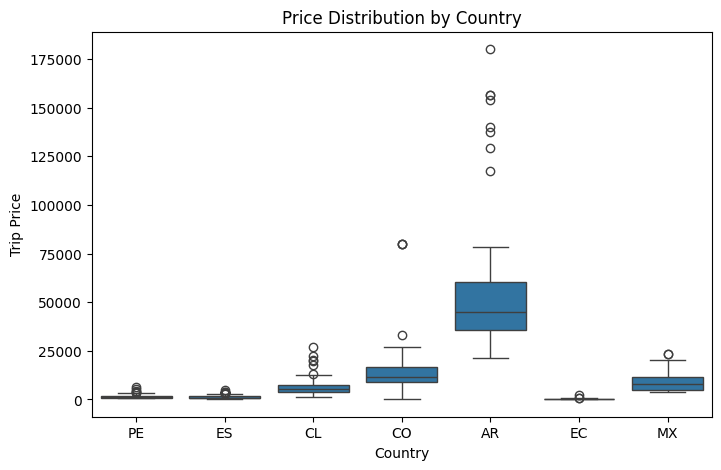

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="locale_country", y="price", data=result)
plt.title("Price Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Trip Price")
plt.show()


The plot shows that trip prices vary considerably between countries. This doesn’t necessarily mean that trips are actually more expensive or cheaper; rather, each country uses its own currency. Therefore, it would be a good idea to convert all prices to a single currency, such as the euro (€), to allow fair comparisons.

### df_cars

In [34]:
query = """
SELECT DISTINCT _id 
FROM cars;
"""

result = con.execute(query).df()
display(result)


,_id
0,JK2ruzP58NI0VhpM71KPVQ==
1,K5GveO0UFaKFCLp01vXfYA==
2,nVK2oCD8JRzhPgUcv7XugQ==
3,TJkSTuJaxTIw4LyqVaqlWA==
4,ekSAqhk6FBlOZsRnIiIRgg==
...,...
14530,3Usbw1czImTu+R84+RoEig==
14531,wF9csKxHSUYSGBSih+PIkg==
14532,55uUafVC5hEpVuLyjp7xjQ==
14533,8r6Tw1QeRZkkj0495Q3RCA==


In [35]:
query = """
SELECT *
FROM cars
WHERE _id = '6c8yRqol/2kVXrVcBZUZhw=='
ORDER BY updated_at
;
"""

result = con.execute(query).df()
display(result)

,_id,licensed,disabled,icon,reg_plate,created_at,updated_at,product_ids
0,6c8yRqol/2kVXrVcBZUZhw==,True,False,lite,/gVAYqTxVcZnf+mr2jBmZA==,2021-10-16 11:58:00.703 UTC,2022-01-07 01:33:22.994 UTC,[]
1,6c8yRqol/2kVXrVcBZUZhw==,True,True,lite,/gVAYqTxVcZnf+mr2jBmZA==,2021-10-16 11:58:00.703 UTC,2022-01-08 15:01:24.442 UTC,"[cf3631bcd4744650d47e025009eb4a36, beedf626e64..."
2,6c8yRqol/2kVXrVcBZUZhw==,True,False,lite,/gVAYqTxVcZnf+mr2jBmZA==,2021-10-16 11:58:00.703 UTC,2022-01-08 15:06:27.118 UTC,[]
3,6c8yRqol/2kVXrVcBZUZhw==,True,True,lite,/gVAYqTxVcZnf+mr2jBmZA==,2021-10-16 11:58:00.703 UTC,2022-01-08 15:06:54.22 UTC,"[cf3631bcd4744650d47e025009eb4a36, beedf626e64..."


This is a perfect example of how, for the same ID, we have multiple versions, depending on `updated_at`, information like `disabled` or `product_ids` has changed. This is a textbook case of an SCD (Slowly Changing Dimension).

## 4. Conclusions and Next Steps in Data Modeling
During this initial exploratory phase, the main tables (`drivers`, `users`, `cars`, and `trips`) were reviewed to understand the overall structure and data quality before building the analytical layer.

### Key findings:
- **Data Structure:**
The dataset contains multiple versions of the same records, especially in the trips table, where each trip can include several rows reflecting different status updates. To simplify modeling, it will be necessary to reduce each trip to a single representative row, keeping only the relevant changes such as driver assignments or status transitions.

    A similar situation occurs in the dimension tables (e.g., drivers, cars, users), where multiple versions of the same entity appear over time. These behave like slowly changing dimensions (SCD), meaning it is important to preserve the historical versions of each record while also identifying the current active one. This ensures historical analyses remain consistent with the business context at the time of each trip.

- **Data Ingestion Quality:**
When ingesting the raw trips dataset, it was not sufficient to simply open and parse the JSON line by line. About 30 rows were corrupted, caused by malformed JSON lines with extra closing braces `}` or incorrect encoding. To address this, a custom function named `load_ndjson` was implemented, using a `repair_line` mechanism to automatically fix and safely parse these corrupted entries during data loading.

- **Entity Relationships:**
While the cars table contains 1,563 car records, only 62 of them are actually referenced in the trips fact table. This indicates that a large portion of the car records are either inactive, unused, or represent historical data that do not directly participate in the current trip dataset. This relationship will need to be validated during the modeling phase to ensure accurate joins and aggregations.

- **Special Driver and Car Records:**
The driver/car with ID `1B2M2Y8AsgTpgAmY7PhCfg==` appears repeatedly and does not correspond to an actual driver (one that appears in the `drivers` table). This record likely represents a placeholder or waiting state in the system and should be treated separately or excluded from analytical computations.

- **Prices and Currency:**
The analysis revealed significant price disparities across countries, explained by the fact that each country records trip prices in its local currency. To enable fair comparisons of fares and revenues, prices should be standardized to a common currency (e.g., euros) using an appropriate conversion factor per country.

- **Data Quality and Consistency:**
Missing or inconsistent values were identified in key fields such as `price`, `reason`, and `locale`. These should be addressed systematically during the staging process to ensure data integrity in downstream layers. 

    Additionally, while almost all records (99.78%) in the trips table include exactly 2 pairs of coordinates (`start_lat`, `start_lon`, `end_lat`, `end_lon`), a small number of entries do not. These incomplete trips will still be loaded into the raw schema to preserve the full source data, but they will be excluded from the final core fact table, since they cannot be reliably used in spatial or route-based analyses.

### Next steps:
1. Load the data into PostgreSQL DB, specifically into the `raw` schema.
1. Implement data cleaning and deduplication logic in the `staging` layer.
2. Build the `core` layer xwith standardized, deduplicated entities and properly defined relationships (`driver`, `user`, `car`, `trip`).
3. Develop the `analytics` layer with aggregated metrics such as driver performance, average trip prices by country, and trip duration statistics.